# Semi-Supervised Label Propagation Classifier

Semi-supervised learning utilizes large unlabeled datasets along with small labeled annotation sets. **Label Propagation** builds similarity graphs across coordinates and iteratively propagates labels from annotated nodes to neighboring unlabeled points. This notebook generates 500 synthetic coordinate points, unlabels 475 samples (setting label=-1), trains a Label Propagation model, and plots the results.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.semi_supervised import LabelPropagation
from sklearn.datasets import make_moons
from sklearn.metrics import classification_report

# Generate 500 synthetic coordinate points (2 classes)
np.random.seed(195)
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)

# Save ground truth labels for validation
y_true = y.copy()

# Randomly select only 25 samples (5%) to remain labeled; set the remaining 475 labels to -1
labeled_indices = np.random.choice(500, size=25, replace=False)
y_semi = np.full(500, -1)
y_semi[labeled_indices] = y_true[labeled_indices]

df_semi = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df_semi['Semi_Label'] = y_semi
df_semi.head(10)



,Feature_1,Feature_2,Semi_Label
0,0.830767,-0.372139,-1
1,0.895032,0.858306,-1
2,1.078857,-0.477753,-1
3,-0.199521,1.006578,-1
4,0.368137,1.238081,-1
5,1.277601,-0.510532,-1
6,1.098480,-0.329066,-1
7,0.081522,1.159076,-1
8,0.553647,0.626288,0
9,1.733153,-0.269697,-1


## Label Propagation Fitting & Evaluation

We fit a Label Propagation classifier using an RBF kernel and calculate prediction accuracy on the originally unlabeled samples.



In [2]:
# Train Label Propagation model
model = LabelPropagation(kernel='rbf', gamma=20)
model.fit(X, y_semi)

# Predict labels across all points
y_pred = model.transduction_

# Evaluate performance on the unlabeled subset
unlabeled_mask = y_semi == -1
accuracy = np.mean(y_pred[unlabeled_mask] == y_true[unlabeled_mask])

print(f"Semi-Supervised Label Propagation Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report Summary:")
print(classification_report(y_true[unlabeled_mask], y_pred[unlabeled_mask]))



Semi-Supervised Label Propagation Accuracy: 98.32%

Classification Report Summary:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       233
           1       1.00      0.97      0.98       242

    accuracy                           0.98       475
   macro avg       0.98      0.98      0.98       475
weighted avg       0.98      0.98      0.98       475



## Semi-Supervised Graph Propagation Visualization

Using Matplotlib, we show the initial state (labeled vs. unlabeled points) and compare it against the final propagated label classes.



<cell>:24: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



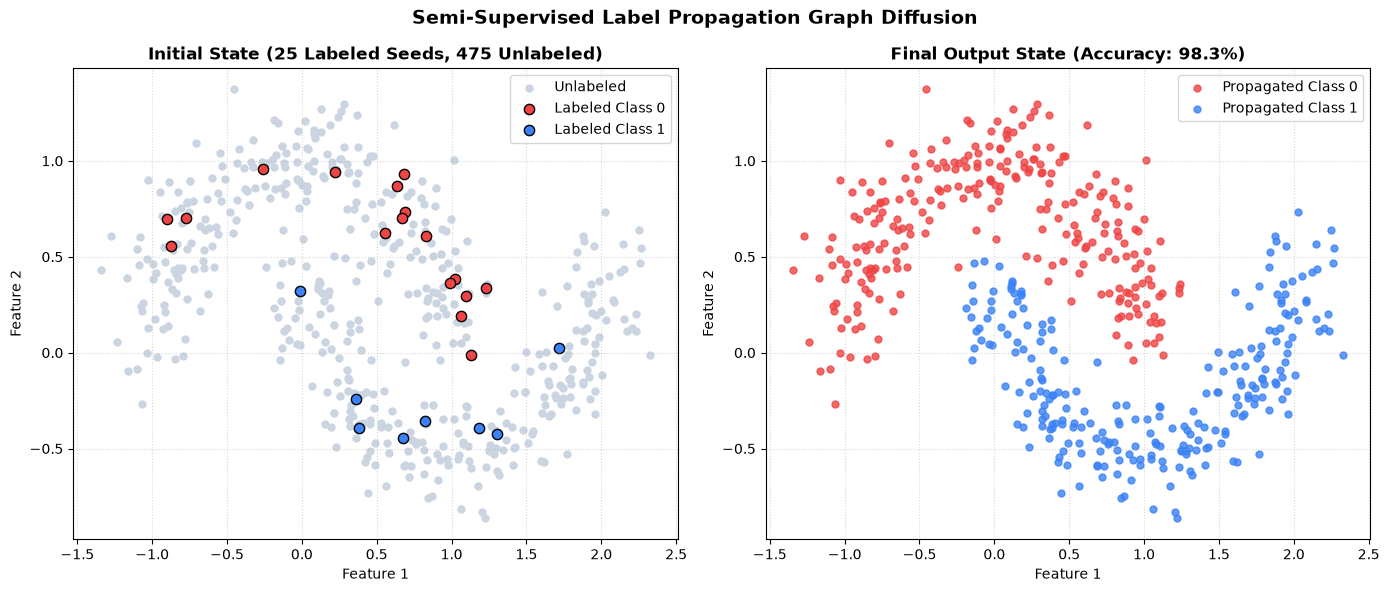

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Initial State (25 labeled points, 475 unlabeled grey points)
ax1.scatter(X[y_semi == -1, 0], X[y_semi == -1, 1], c='#CBD5E1', s=25, label='Unlabeled')
ax1.scatter(X[y_semi == 0, 0], X[y_semi == 0, 1], c='#EF4444', edgecolors='k', s=55, label='Labeled Class 0')
ax1.scatter(X[y_semi == 1, 0], X[y_semi == 1, 1], c='#3B82F6', edgecolors='k', s=55, label='Labeled Class 1')
ax1.set_title('Initial State (25 Labeled Seeds, 475 Unlabeled)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Final Propagated Output
ax2.scatter(X[y_pred == 0, 0], X[y_pred == 0, 1], c='#EF4444', s=25, alpha=0.8, label='Propagated Class 0')
ax2.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], c='#3B82F6', s=25, alpha=0.8, label='Propagated Class 1')
ax2.set_title(f'Final Output State (Accuracy: {accuracy*100:.1f}%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Semi-Supervised Label Propagation Graph Diffusion', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
